# Control Panel For All Project
Its primary purpose is to easily gather data and run all experiments performed during project and see their results.

In [1]:
from pathlib import Path
import sys
import os

# If notebook is opened from /notebooks, move working directory to project root
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Data processed exists:", (PROJECT_ROOT / "data" / "processed").exists())

Current working directory: c:\Users\krzys\OneDrive\Pulpit\Studia\StudiaDS\2sem\MLDSt\Project\Concept-Drift-Detector
Project root: c:\Users\krzys\OneDrive\Pulpit\Studia\StudiaDS\2sem\MLDSt\Project\Concept-Drift-Detector
Data processed exists: True


In [2]:
from src.data_acquisition import run_data_pipeline
from src.experiments import (
    basic_synthetic,
    advanced_synthetic,
    baseline_balanced_real,
    baseline_extracted_real,
    transformer_extracted_real,
)

c:\Users\krzys\OneDrive\Pulpit\Studia\StudiaDS\2sem\MLDSt\Project\Concept-Drift-Detector\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Run full data acquisition / processing pipeline CHECK FLAGS STATUS
run_data_pipeline(
    run_scraping=False,
    run_partitioning=True,
    run_sampling=True
)


=== STEP 2: PARTITIONING ===
Starting partitioning
Input file:  data\raw\articles_raw.jsonl
Output dir:  data\processed

Finished partitioning
Total rows read:     216
Saved rows:          216
Invalid rows skipped:0
Output dir:          data\processed

=== STEP 3: BALANCED STREAM ===
Processing data\processed\2025\12.jsonl
Processing data\processed\2026\01.jsonl
Processing data\processed\2026\02.jsonl
Processing data\processed\2026\03.jsonl
Processing data\processed\2026\04.jsonl

=== STEP 4: DAILY STREAM ===
Processing data\processed\2025\12.jsonl
Processing data\processed\2026\01.jsonl
Processing data\processed\2026\02.jsonl
Processing data\processed\2026\03.jsonl
Processing data\processed\2026\04.jsonl

=== DONE ===



Step 800: CONCEPT DRIFT INITIATED
Step 832: Concept drift detected on Model 1

Step 1600: CONCEPT DRIFT INITIATED
Step 1633: Concept drift detected on Model 2

Step 2400: CONCEPT DRIFT INITIATED
Step 2434: Concept drift detected on Model 3


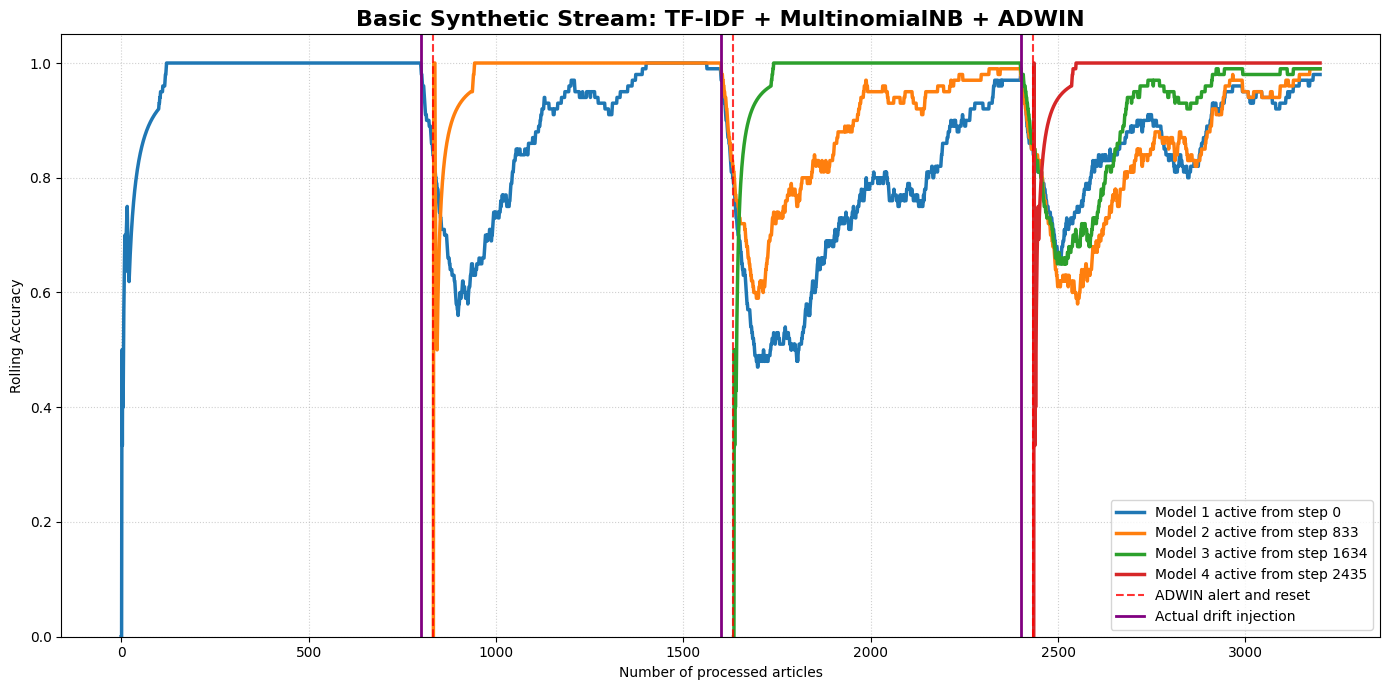

In [14]:
# Run basic synthetic experiment
basic_synthetic()

SCHEDULED: Gradual Drift from 1500 to 2000 (45 words)

Step 800: CONCEPT DRIFT INITIATED
Step 832: Concept drift detected on Model 1
Step 2017: Concept drift detected on Model 2

Step 3000: RECURRING CONCEPT INITIATED
Step 3042: Concept drift detected on Model 3


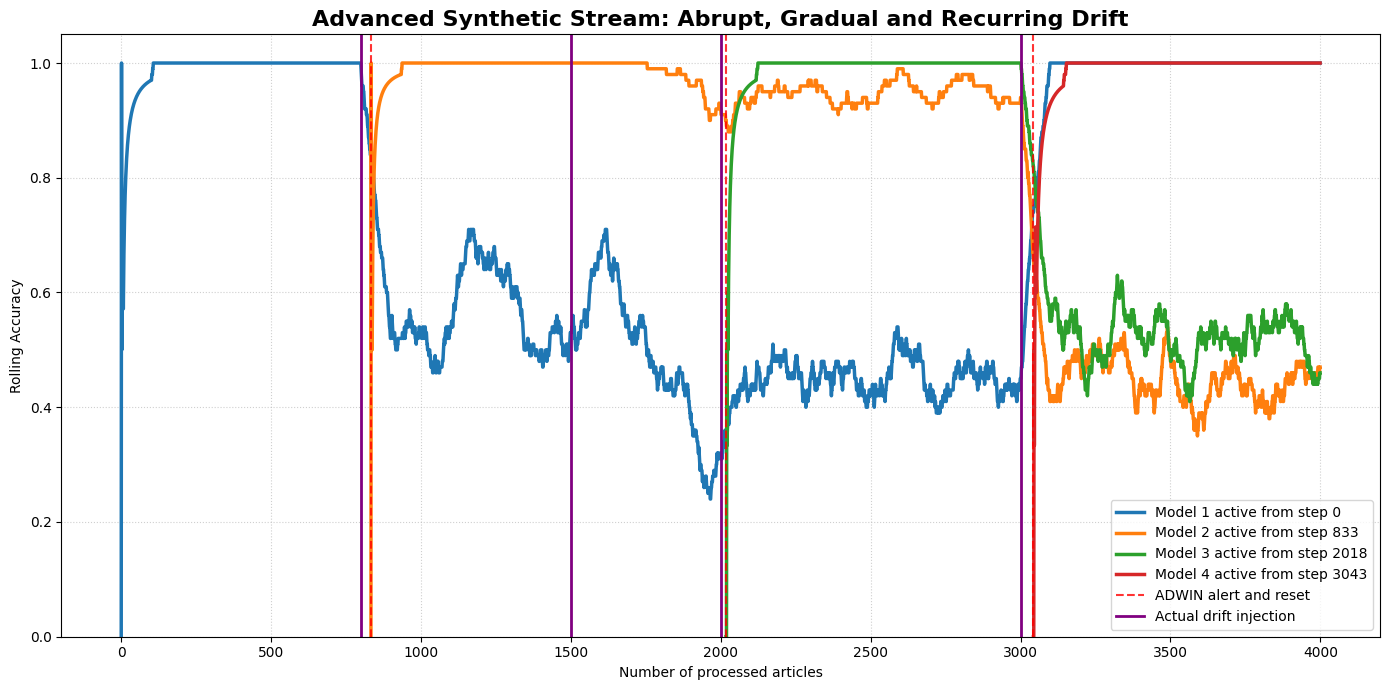

In [4]:
# Run advanced synthetic experiment
advanced_synthetic()

In [18]:
# Run real-data TF-IDF + NB experiment on balanced stream
baseline_balanced_real()

Processing data\processed\2025\12.jsonl
Processing data\processed\2026\01.jsonl
Processing data\processed\2026\02.jsonl
Processing data\processed\2026\03.jsonl
Processing data\processed\2026\04.jsonl
Loaded samples: 0
No data loaded. Check DATA_DIR or class balance.


Processing data\processed\2025\12.jsonl
Processing data\processed\2026\01.jsonl
Processing data\processed\2026\02.jsonl
Processing data\processed\2026\03.jsonl
Processing data\processed\2026\04.jsonl
Loaded samples: 73


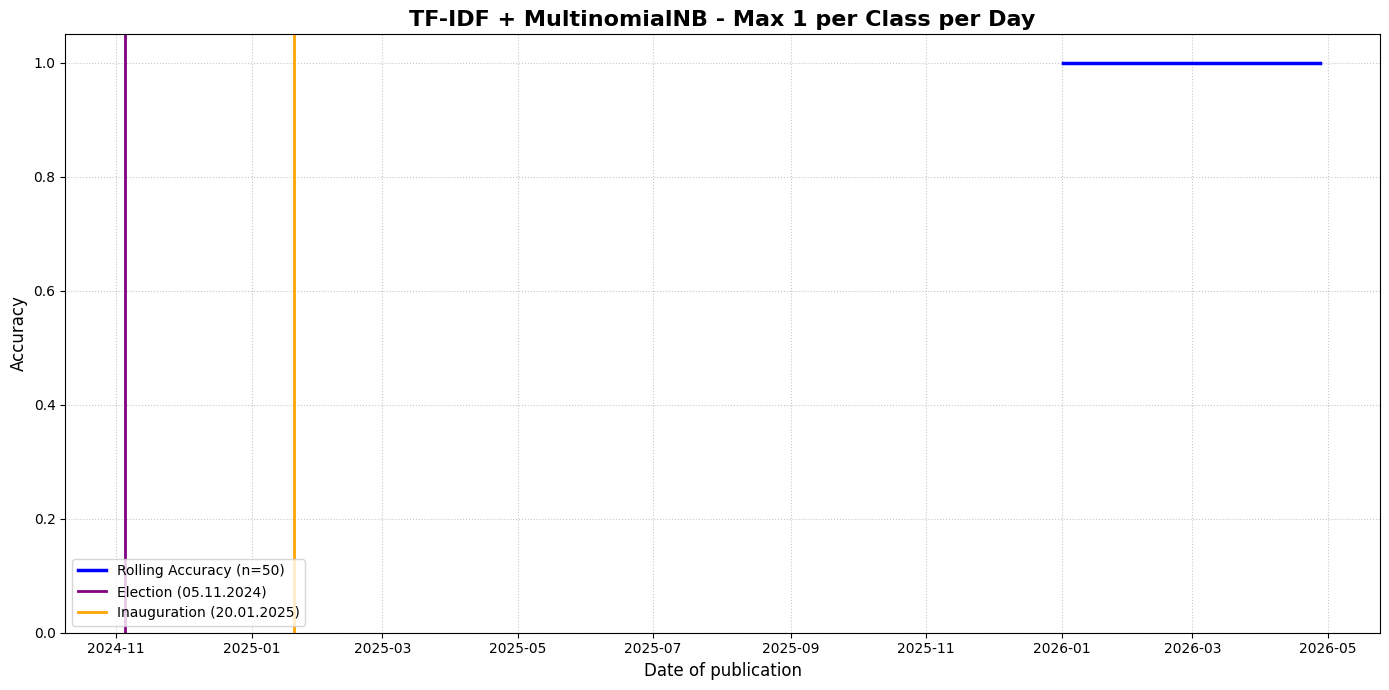

In [16]:
# Run real-data TF-IDF + NB experiment on extracted daily stream
baseline_extracted_real()

Processing data\processed\2025\12.jsonl
Processing data\processed\2026\01.jsonl
Processing data\processed\2026\02.jsonl
Processing data\processed\2026\03.jsonl
Processing data\processed\2026\04.jsonl
Loaded samples: 73
Loading SentenceTransformer model 'all-MiniLM-L6-v2'...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3395.02it/s]


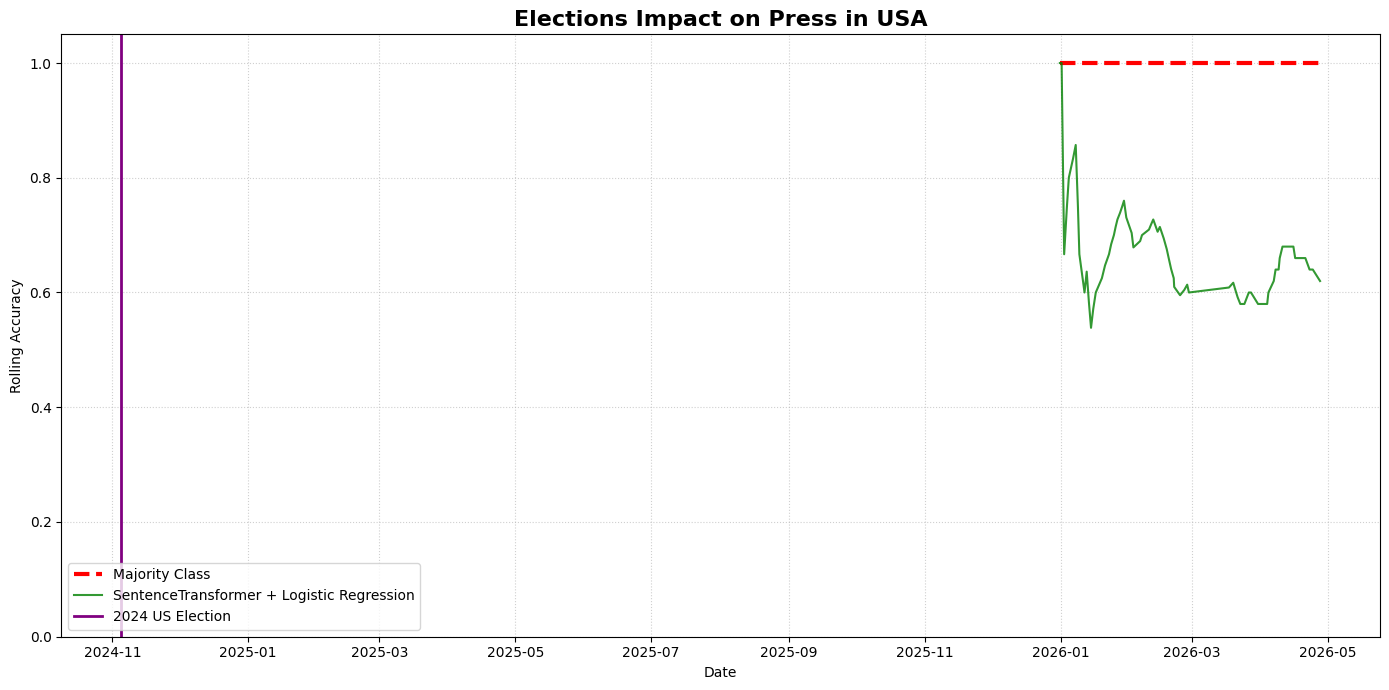

In [17]:
# Run transformer-based experiment on extracted real stream
transformer_extracted_real()